In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\4. June"
analytical_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"
postprocess_folder = os.path.join(base_folder, "postprocess3")

## Evert's Whole-Space Solution

In [2]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_air_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert_air = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

## My Air Solutions

In [3]:
# base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\3.b May-Final"
electric_file = os.path.join(base_folder, "out_x", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1]

labels = [
    r'x',
]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48]  # customize as needed for each e_data_elfe
num_rec_bs_list = [0,0, 0, 0, 0, 0, 0]
num_rec_ob_list = [0,0, 0, 0, 0, 0, 0]

dataset_elfe_air = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]
    num_rec_bs = num_rec_bs_list[i]
    num_rec_ob = num_rec_ob_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    # Broadside
    i_rx_bs = num_rec_ef
    abs_bs = abs_Ex_elfe[i_rx_bs:i_rx_bs + num_rec_bs]
    phase_bs = phase_Ex_elfe[i_rx_bs:i_rx_bs + num_rec_bs]
    real_bs = real_Ex_elfe[i_rx_bs:i_rx_bs + num_rec_bs]
    imag_bs = imag_Ex_elfe[i_rx_bs:i_rx_bs + num_rec_bs]
    r_bs = rec_y_elfe[i_rx_bs:i_rx_bs + num_rec_bs]

    # Oblique
    i_rx_ob = num_rec_bs + num_rec_ef
    abs_ob = abs_Ex_elfe[i_rx_ob:i_rx_ob + num_rec_ob]
    phase_ob = phase_Ex_elfe[i_rx_ob:i_rx_ob + num_rec_ob]
    real_ob = real_Ex_elfe[i_rx_ob:i_rx_ob + num_rec_ob]
    imag_ob = imag_Ex_elfe[i_rx_ob:i_rx_ob + num_rec_ob]
    r_ob = np.sqrt(rec_x_elfe[i_rx_ob:i_rx_ob + num_rec_ob]**2 + rec_y_elfe[i_rx_ob:i_rx_ob + num_rec_ob]**2)

    dataset_elfe_air.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))
    dataset_elfe_air.append((abs_bs, phase_bs, real_bs, imag_bs, 'Broadside', r_bs, labels[i]))
    dataset_elfe_air.append((abs_ob, phase_ob, real_ob, imag_ob, 'Oblique', r_ob, labels[i]))


## Comparing Air-Space Solutions

### Direct Plot

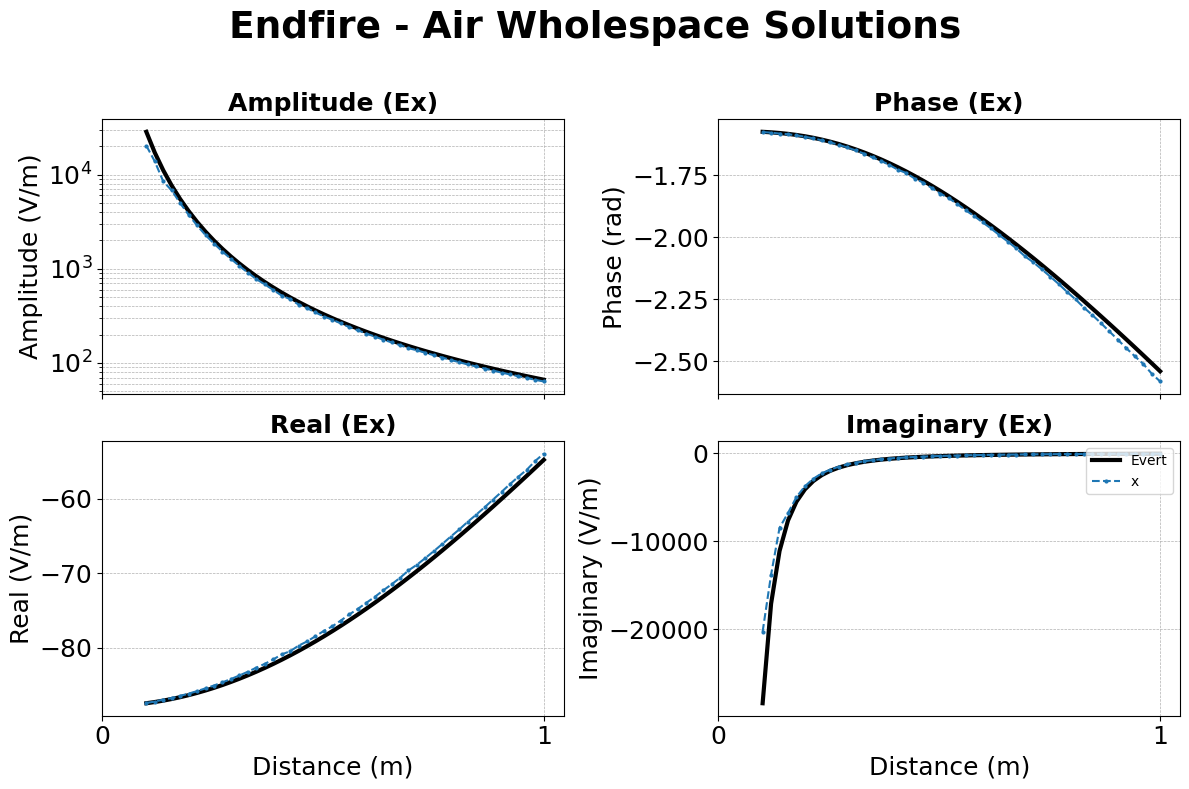

In [4]:
# Use datasets from both Evert and empymod
datasets_air = dataset_evert_air + dataset_elfe_air

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 10

# Style options
colors = ['#000000', 'green', '#1f77b4', '#ff00ff', '#6a0dad', "#0e0ace", "#ff00b3", "#ff7f0e"]
linestyles = ['-', '-', '--', ':', '--', ':', '--', ':']
markers = ['', '', 'o', 's', 'v', 'X', 'D', 'P']

# Style options for different data origins
origin_styles = {
    'Evert': {'color': colors[0], 'linestyle': linestyles[0], 'marker': markers[0]},
    labels[0]: {'color': colors[2], 'linestyle': linestyles[2], 'marker': markers[2]},
    # labels[1]: {'color': colors[3], 'linestyle': linestyles[3], 'marker': ''},
    # labels[2]: {'color': colors[4], 'linestyle': '-.', 'marker': ''},
    # labels[3]: {'color': colors[5], 'linestyle': linestyles[5], 'marker': ''},
    # labels[4]: {'color': colors[6], 'linestyle': linestyles[6], 'marker': ''},
    # labels[5]: {'color': colors[7], 'linestyle': linestyles[7], 'marker': 'x'}
}

normal_lw = 2.0
# Plot only for Endfire orientation
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# Filter datasets for Endfire orientation
orientation_datasets = [ds for ds in datasets_air if ds[4] == orientation]
for j, (title, ylabel) in enumerate(quantities):
    ax = axes[j // 2, j % 2]
    for ds in orientation_datasets:
        amp, phase, real, imag, label, axis, source = ds
        style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
        plot_label = source
        data = [amp, phase, real, imag][j]
        if source in ['Evert', 'empymod - 2001 DLF']:
            lw = normal_lw * 1.5
            ms = 2
        else:
            lw = normal_lw * 0.75
            ms = 2
        if j == 0:
            ax.semilogy(axis, data, label=plot_label, color=style['color'],
                        linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=ms)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        else:
            ax.plot(axis, data, label=plot_label, color=style['color'],
                    linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=ms)
            ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=font_label, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=font_label)
    if j // 2 == 1:
        ax.set_xlabel('Distance (m)', fontsize=font_label)
    if axis.size > 0:
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
    ax.tick_params(axis='both', which='major', labelsize=font_tick)
    if j == 3:
        ax.legend(fontsize=font_legend, loc='upper right')
fig.suptitle(f"{orientation} - Air Wholespace Solutions", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname = f"5_air_solution_comparison_{orientation.lower()}.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()


### Error Plot

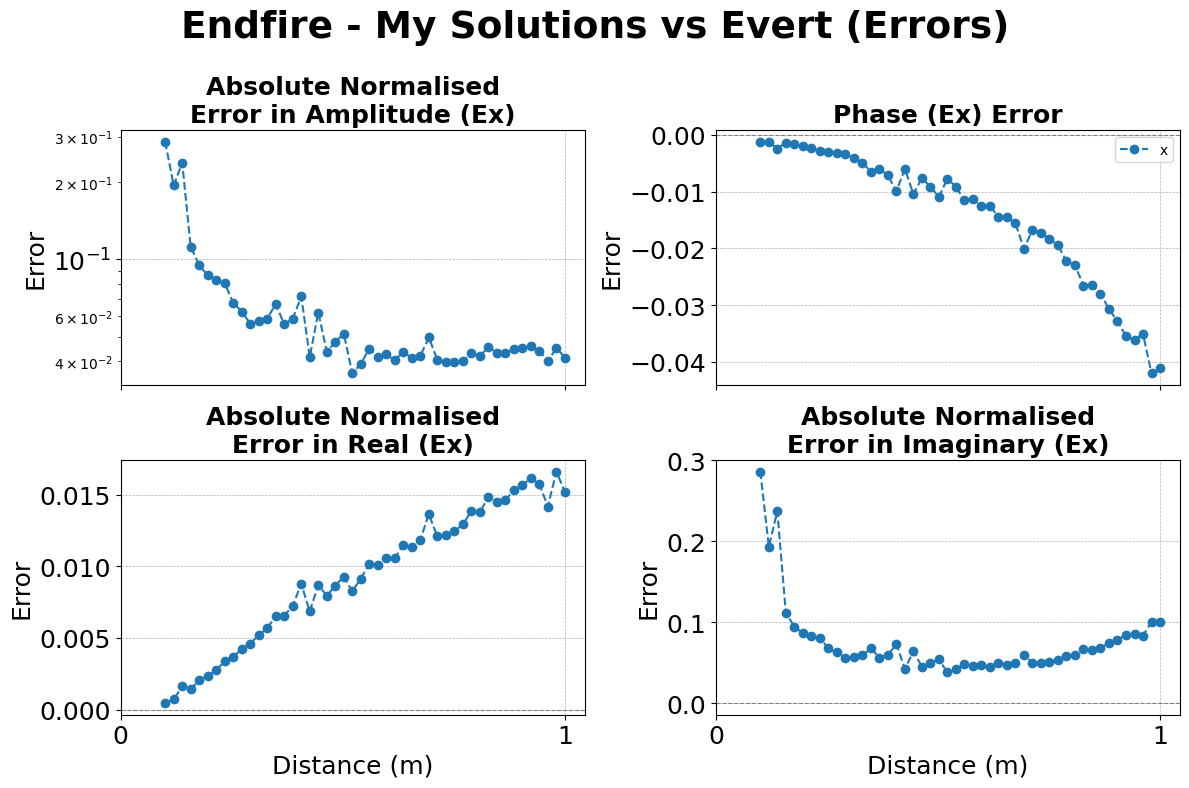

In [5]:
def compute_errors_with_interp(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        ref_r = ref[5]
        elfe_r = elfe[5]
        # Interpolate reference data if radii do not match
        if len(ref_r) != len(elfe_r) or not np.allclose(ref_r, elfe_r):
            ref_data_interp = np.interp(elfe_r, ref_r, ref_data)
        else:
            ref_data_interp = ref_data
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data_interp) / np.abs(ref_data_interp)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data_interp
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

# --- set up the figure just once ---
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# --- pick only Endfire ELFE datasets ---
elfe_endfire = [ds for ds in dataset_elfe_air if ds[4] == orientation]

# --- loop over each Endfire dataset ---
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds    # we ignore ds[4] here
    style = origin_styles.get(source, {'color':'gray','linestyle':'-','marker':''})
    lw = normal_lw * 0.75

    # compute errors vs. your first Evert reference
    amp_err, phase_err, real_err, imag_err, r_err = compute_errors_with_interp(dataset_evert_air[0], ds)
    err_data = [amp_err, phase_err, real_err, imag_err]

    # plot into each of the four subplots
    for k, ax in enumerate(axes.flat):
        ax.plot(r_err, err_data[k],
                label=source,
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=lw)
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, linestyle='--', linewidth=0.5)

        if k == 0:
            ax.set_yscale('log')

        # give each panel its appropriate title
        title_base = quantities[k][0]
        if k in [0, 2, 3]:
            ax.set_title(f"Absolute Normalised\nError in {title_base}",
                         fontsize=font_label, fontweight='bold')
        else:
            ax.set_title(f"{title_base} Error",
                         fontsize=font_label, fontweight='bold')

        # only bottom‐row panels get an x‐label
        if k // 2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)

        # nice 1 m tick spacing
        if r_err.size:
            start = np.floor(r_err.min() * 2) / 2
            stop  = np.ceil (r_err.max() * 2) / 2 + 0.01
            ax.set_xticks(np.arange(start, stop, 1.0))

        ax.tick_params(axis='both', which='major', labelsize=font_tick)

# single legend in the upper-right of the first row
axes[0,1].legend(fontsize=font_legend, loc='best')

fig.suptitle(f"{orientation} - My Solutions vs Evert (Errors)",
             fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])

# save & show
fname = f"6_elfe_vs_evert_{orientation.lower()}_error.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()
